In [ ]:
!pip install tensorflow opencv-python matplotlib numpy scikit-learn

In [ ]:
import zipfile
import os

zip_path = "/content/archive (2).zip"

extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
import os

os.listdir("/content/brain_tumor_dataset")

['yes', 'no', 'brain_tumor_dataset']

In [ ]:
import os

print("YES images:", len(os.listdir("/content/brain_tumor_dataset/yes")))
print("NO images :", len(os.listdir("/content/brain_tumor_dataset/no")))

YES images: 155
NO images : 98


In [ ]:
import os

print(os.listdir("/content/brain_tumor_dataset/brain_tumor_dataset"))

['yes', 'no']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    "/content/brain_tumor_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    "/content/brain_tumor_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 406 images belonging to 3 classes.
Found 100 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(1,activation='sigmoid')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 449ms/step - accuracy: 0.2020 - loss: 0.7479 - val_accuracy: 0.1900 - val_loss: 0.5037
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.2167 - loss: 0.6193 - val_accuracy: 0.1900 - val_loss: 0.3318
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 232ms/step - accuracy: 0.1946 - loss: 0.5560 - val_accuracy: 0.1900 - val_loss: 0.4308
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.1946 - loss: 0.5552 - val_accuracy: 0.1900 - val_loss: 0.3251
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 238ms/step - accuracy: 0.1946 - loss: 0.5292 - val_accuracy: 0.1900 - val_loss: 0.4147
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.1946 - loss: 0.5172 - val_accuracy: 0.1900 - val_loss: 0.3621
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step - accuracy: 0.1946 - loss: 0.5269 - val_accuracy: 0.1900 - val_loss: 0.3565
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step - accuracy: 0.1946 - loss: 0.5392 - val_accuracy: 0

In [ ]:
import os

print(os.listdir("/content/brain_tumor_dataset"))

['yes', 'no', 'brain_tumor_dataset']


In [ ]:
print(os.listdir("/content/brain_tumor_dataset/brain_tumor_dataset"))

['yes', 'no']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    "/content/brain_tumor_dataset/brain_tumor_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

validation_data = train_datagen.flow_from_directory(
    "/content/brain_tumor_dataset/brain_tumor_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 589ms/step - accuracy: 0.5271 - loss: 0.8910 - val_accuracy: 0.7200 - val_loss: 0.5802
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - accuracy: 0.7143 - loss: 0.5872 - val_accuracy: 0.7200 - val_loss: 0.5737
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.7094 - loss: 0.6078 - val_accuracy: 0.7200 - val_loss: 0.5388
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.7734 - loss: 0.5706 - val_accuracy: 0.7400 - val_loss: 0.5780
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.7094 - loss: 0.5932 - val_accuracy: 0.7600 - val_loss: 0.5416
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step - accuracy: 0.7389 - loss: 0.5528 - val_accuracy: 0.6800 - val_loss: 0.6132
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.7340 - loss: 0.5734 - val_accuracy: 0.7400 - val_loss: 0.5370
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.7340 - loss: 0.6015 - val_accuracy: 0

In [ ]:
model.save("brain_tumor_model.keras")
print("Model saved successfully!")

Model saved successfully!


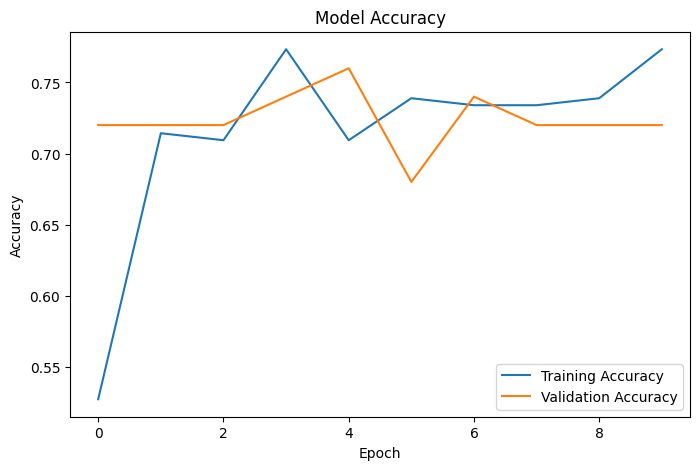

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

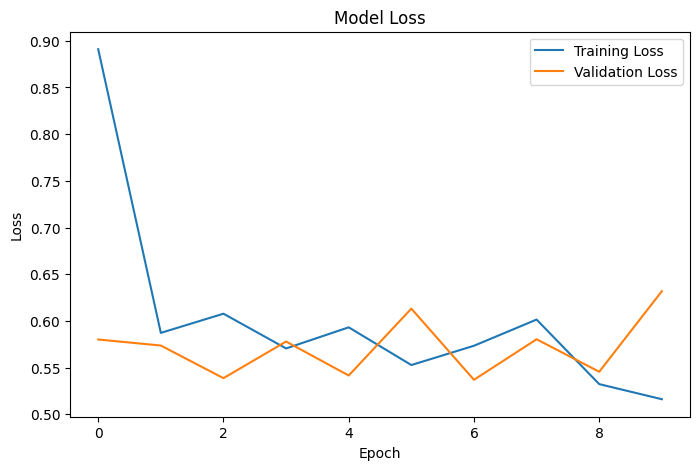

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
from google.colab import files

files.download("brain_tumor_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6355 - loss: 0.7100 - val_accuracy: 0.8000 - val_loss: 0.4051
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.7980 - loss: 0.4403 - val_accuracy: 0.9000 - val_loss: 0.2589
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 0.8719 - loss: 0.3669 - val_accuracy: 0.9000 - val_loss: 0.2662
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.8670 - loss: 0.3213 - val_accuracy: 0.9400 - val_loss: 0.1690
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.8916 - loss: 0.2565 - val_accuracy: 0.9600 - val_loss: 0.1872
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.8867 - loss: 0.3037 - val_accuracy: 0.9800 - val_loss: 0.1885
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step - accuracy: 0.8916 - loss: 0.2287 - val_accuracy: 0.8800 - val_loss: 0.2361
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.9064 - loss: 0.2070 - val_accuracy: 0.92

In [ ]:
model.save("brain_tumor_mobilenet.keras")

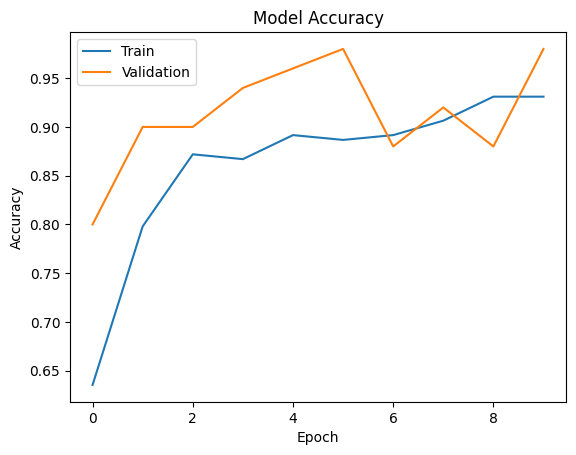

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

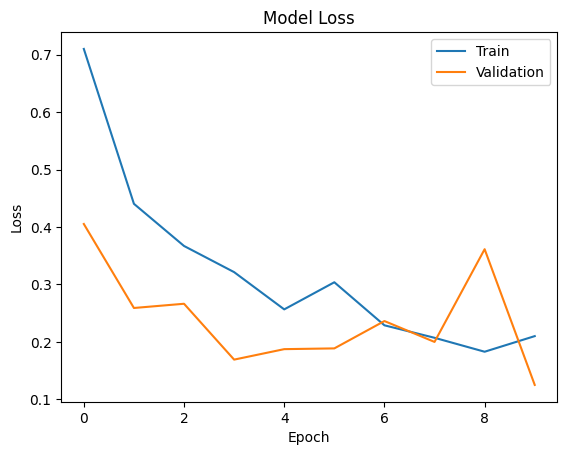

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
model.save("brain_tumor_model.keras")
print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Y1.jpg to Y1.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction Score: 0.98777485
🧠 Tumor Detected


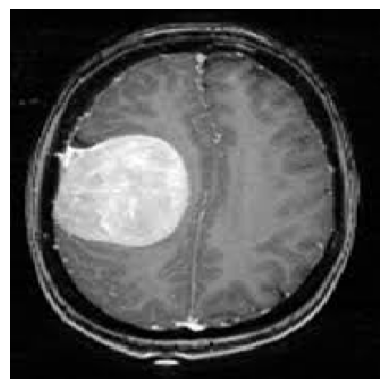

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    "/content/Y1.jpg",
    target_size=(224,224)
)

plt.imshow(img)
plt.axis("off")

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print("Prediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("🧠 Tumor Detected")
else:
    print("✅ No Tumor Detected")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 5 no.jpg to 5 no.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction Score: 0.019383343
✅ No Tumor Detected


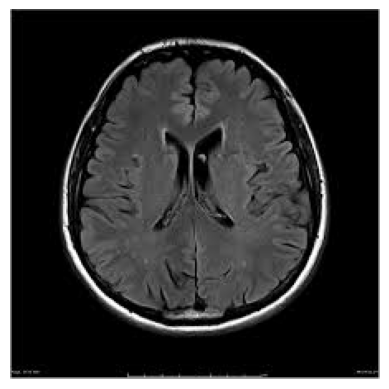

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    "/content/5 no.jpg",
    target_size=(224,224)
)

plt.imshow(img)
plt.axis("off")

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print("Prediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("🧠 Tumor Detected")
else:
    print("✅ No Tumor Detected")